In [ ]:
import os
os.environ['HF_HOME'] = '/mnt/datadisk/Mehdi'
from sae_lens import SAE
from feature_sensitivity_cache import load_indices_json

import json
import networkx as nx
import numpy as np 
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_sensitivity_cache import load_indices_json

/home/mahdi/miniconda3/envs/soft_reasoning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sae = SAE.from_pretrained('gemma-scope-2b-pt-res-canonical', 'layer_25/width_16k/canonical', device = 'cpu')

In [3]:
cached = load_indices_json('cache/google__gemma-2-2b/gemma-scope-2b-pt-res-canonical/layer_25__width_16k__canonical/e58a85b6bf439f7dff69e9b1401bcdc11888ff41/indices.json')['top_k_indices']
print(cached)
SAE_vectors = sae[0].W_dec[cached].detach().numpy()
print(SAE_vectors.shape)

[10409, 5200, 7160, 2149, 11525, 11100, 15416, 12013, 4456, 989, 8061, 2206, 439, 1892, 14630]
(15, 2304)


In [4]:
def list_json_file_paths(directory):
    return [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.endswith('.json') and (not f.startswith('config')) and os.path.isfile(os.path.join(directory, f))
    ][:-1]
def build_tree_from_dict(tree_dict, graph=None, parent=None):
    if graph is None:
        graph = nx.DiGraph()
    # Add node with attribute
    depth = tree_dict['depth']
    weights = tree_dict['weights'] if tree_dict['weights']!=None else []
    graph.add_node(tree_dict['id'], depth=depth, weights=weights)
    # Add edge from parent to current
    if parent is not None:
        graph.add_edge(parent, tree_dict['id'])
    # Recurse for children
    for child in tree_dict.get('children', []):
        build_tree_from_dict(child, graph, tree_dict['id'])
    return graph


def get_weights(solutions):
    all_weights = []
    for jsn in solutions:
        with open(jsn, 'r') as fin:
            solution = json.load(fin)
        # print(solution)
        G = build_tree_from_dict(solution['tree_lists'])
        temp = [(n, data['depth'], data['weights']) for n, data in G.nodes(data=True) if data['depth']!=[]]
        all_weights+=temp
    return all_weights

def mutual_correlation(vectors):
    arr = np.stack([np.asarray(v).ravel() for v in vectors])
    return np.corrcoef(arr)

def mutual_covariance(vectors):
    arr = np.stack([np.asarray(v).ravel() for v in vectors])
    return np.cov(arr)

def cos_similarity(vectors, eps=1e-12):
    X = np.stack([np.asarray(v).ravel() for v in vectors]).astype(float)
    norms = np.linalg.norm(X, axis=1)
    norms = np.maximum(norms, eps)
    X_normalized = X / norms[:, None]
    return X_normalized @ X_normalized.T

def plot_heatmap_with_borders(data, border_interval=5, lines=False):
    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(data, cmap='plasma', cbar=True, linewidths=0.5, linecolor='gray')
    
    if lines:
        # Add borders every 'border_interval' cells
        n = data.shape[0]
        for i in range(0, n, border_interval):
            ax.axhline(i, color='black', linewidth=2)
            ax.axvline(i, color='black', linewidth=2)

        # Add final border lines at the end
        ax.axhline(n, color='black', linewidth=2)
        ax.axvline(n, color='black', linewidth=2)

    plt.title(f'Heatmap with Borders Every {border_interval} Cells')
    plt.show()

In [5]:
solutions = list_json_file_paths('output/gsm8k/gemma-2-2b/27_051054')
depth_weights = get_weights(solutions)
print(depth_weights)

[(0, 0, []), (1, 1, [[0.8952318429946899, 0.5436463356018066, 0.32588955760002136, 0.6701710224151611, 0.4058205485343933, 0.6941206455230713, 0.0, 0.7512112259864807, 0.47583022713661194, 0.9534653425216675, 1.0, 0.039556462317705154, 0.4934406578540802, 0.6843428015708923, 0.5562958717346191]]), (2, 1, [[0.48462310433387756, 0.6547134518623352, 0.0, 0.7836264371871948, 0.2659298777580261, 1.0, 0.6107945442199707, 0.42875930666923523, 0.28531867265701294, 0.5360850691795349, 0.8541914224624634, 0.19633489847183228, 0.3823576867580414, 0.4696390628814697, 0.6839832067489624]]), (3, 1, [[0.0, 0.2682160437107086, 0.5756374001502991, 0.8160532116889954, 0.6242554783821106, 0.4762464761734009, 0.518369734287262, 0.499185711145401, 0.2958815395832062, 0.22895292937755585, 1.0, 0.4486110210418701, 0.1703934520483017, 0.9137991666793823, 0.6330029368400574]]), (4, 1, [[0.3219817876815796, 0.15335948765277863, 0.09265817701816559, 0.35642847418785095, 0.20546835660934448, 0.4436751902103424, 0

20


/tmp/ipykernel_2748786/2471399184.py:25: RuntimeWarning: invalid value encountered in divide
  heatmap = heatmap/scale


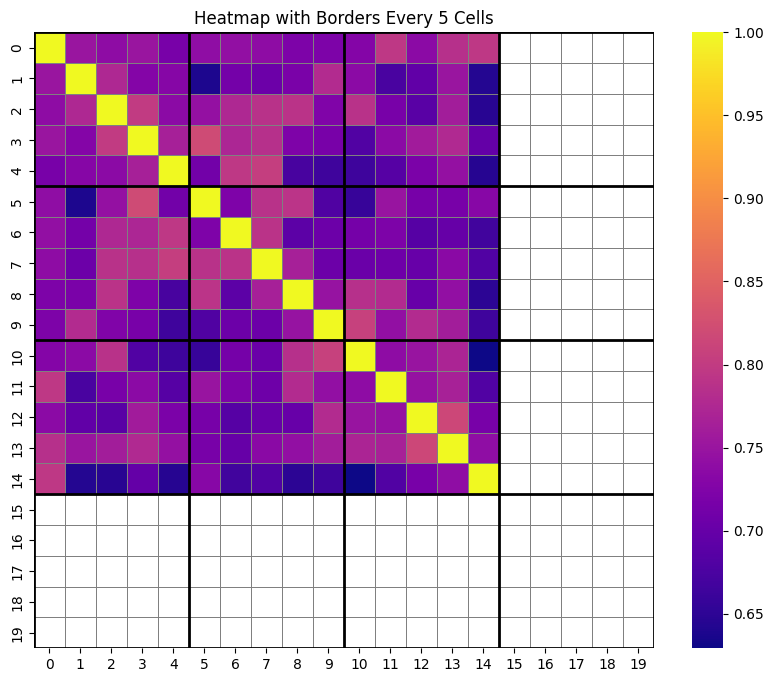

In [6]:
correlations = []
temp = []
for item in depth_weights[1:]:
    if item[0]!=0:

        result = np.array(item[-1][0]) @ SAE_vectors                 # shape (1, 2304)
        result = result.squeeze()            # shape (2304,)

        temp.append(result)
        # print(temp)
    else:
        if len(temp)==15:
            correlations.append(cos_similarity(temp))
        temp=[]
max_depth = max(item[1] for item in depth_weights)
heatmap_size = 5*max_depth
print(heatmap_size)
heatmap = np.zeros(shape=(heatmap_size, heatmap_size))
scale = np.zeros(shape=(heatmap_size, heatmap_size))
for core_mat in correlations:
    for i in range(core_mat.shape[0]):
        for j in range(core_mat.shape[1]):
            heatmap[i, j]+=core_mat[i, j]
            scale[i, j]+=1
heatmap = heatmap/scale



plot_heatmap_with_borders((heatmap[:20, :20]).astype(float), lines=True)


In [7]:
print(np.mean(heatmap[:5, :5]), np.mean(heatmap[5:10, 5:10]), np.mean(heatmap[10:15, 10:15]), np.mean(heatmap[15:20, 15:20]))

0.7991491078365658 0.7905919345323771 0.7882125763700967 nan


In [8]:
averages = {}
for dw in depth_weights:
    if dw[2]!=[]:
        if dw[1] not in averages:
            averages[dw[1]]=[]
        averages[dw[1]].append(dw[2][0])



In [9]:
averages.keys()

dict_keys([1, 2, 3, 4])

In [10]:
ranks = []
for k in averages:
    print(np.round(np.mean(np.array(averages[k]), axis=0), 2))
    ranks.append(np.round(np.mean(np.array(averages[k]), axis=0), 2).tolist())

print(ranks)

[0.49 0.51 0.51 0.52 0.5  0.51 0.54 0.5  0.51 0.52 0.5  0.49 0.47 0.51
 0.48]
[0.48 0.46 0.54 0.46 0.44 0.45 0.43 0.52 0.47 0.44 0.57 0.49 0.43 0.54
 0.46]
[0.41 0.41 0.53 0.56 0.36 0.5  0.35 0.41 0.42 0.64 0.48 0.57 0.23 0.37
 0.4 ]
[0.42 0.84 0.58 0.84 0.53 0.3  0.44 0.54 0.14 0.25 0.12 0.5  0.96 0.32
 0.46]
[[0.49, 0.51, 0.51, 0.52, 0.5, 0.51, 0.54, 0.5, 0.51, 0.52, 0.5, 0.49, 0.47, 0.51, 0.48], [0.48, 0.46, 0.54, 0.46, 0.44, 0.45, 0.43, 0.52, 0.47, 0.44, 0.57, 0.49, 0.43, 0.54, 0.46], [0.41, 0.41, 0.53, 0.56, 0.36, 0.5, 0.35, 0.41, 0.42, 0.64, 0.48, 0.57, 0.23, 0.37, 0.4], [0.42, 0.84, 0.58, 0.84, 0.53, 0.3, 0.44, 0.54, 0.14, 0.25, 0.12, 0.5, 0.96, 0.32, 0.46]]


In [11]:
for idx, item in enumerate(ranks[1:]):
    temp = sorted(item)
    print(f'Iteration number {idx+1}')
    print([temp.index(element) for element in item])

Iteration number 1
[9, 5, 12, 5, 2, 4, 0, 11, 8, 2, 14, 10, 0, 12, 5]
Iteration number 2
[5, 5, 11, 12, 2, 10, 1, 5, 8, 14, 9, 13, 0, 3, 4]
Iteration number 3
[5, 12, 11, 12, 9, 3, 6, 10, 1, 2, 0, 8, 14, 4, 7]


20


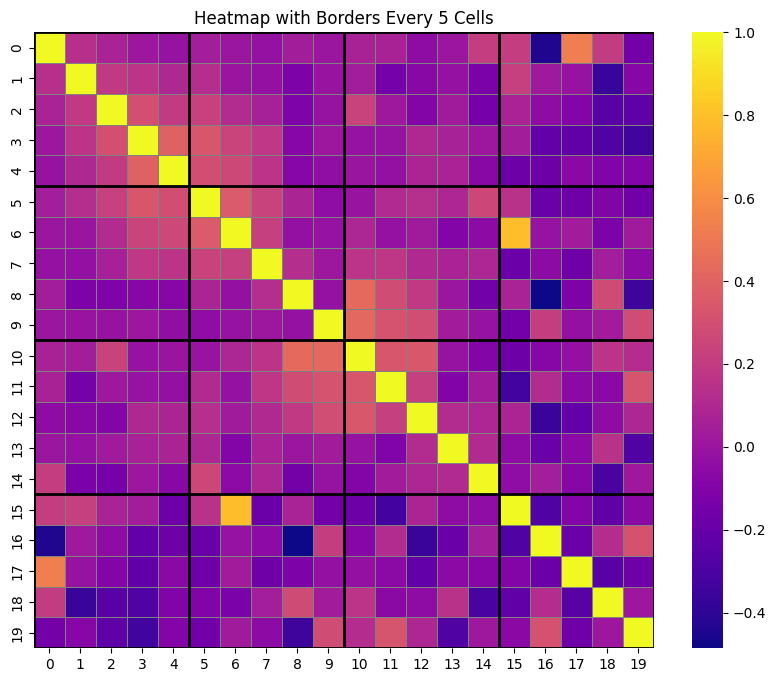

In [12]:
correlations = []
temp = []
for item in depth_weights[1:]:
    if item[0]!=0:
        temp.append(item[-1][0])
        # print(temp)
    else:
        correlations.append(mutual_correlation(temp))
        temp=[]
max_depth = max(item[1] for item in depth_weights)
heatmap_size = 5*max_depth
print(heatmap_size)
heatmap = np.zeros(shape=(heatmap_size, heatmap_size))
scale = np.zeros(shape=(heatmap_size, heatmap_size))
for core_mat in correlations:
    for i in range(core_mat.shape[0]):
        for j in range(core_mat.shape[1]):
            heatmap[i, j]+=core_mat[i, j]
            scale[i, j]+=1
heatmap = heatmap/scale



plot_heatmap_with_borders(heatmap[:20, :20], lines=True)

        



In [13]:
print(np.mean(heatmap[:5, :5]), np.mean(heatmap[5:10, 5:10]), np.mean(heatmap[10:15, 10:15]), np.mean(heatmap[15:20, 15:20]))

0.3239080547564546 0.2746152060928507 0.28202804412333826 0.13425183733014617


In [14]:
all_depth = list(set([item[1] for item in all_thoughts]))

for d in all_depth:
    temp = np.zeros(15)
    for _, de, we in all_thoughts:
        if de==d:
            for l in we:
                temp+=np.array(l)
                # print(l)
    print(d, temp)

NameError: name 'all_thoughts' is not defined

{'id': 0, 'question': None, 'depth': 0, 'guide_embedding': '[i.tolist() for i in self.guide_embedding] if self.guide_embedding is not None else None', 'standard_answer': None, 'model_answer': None, 'cot_answer': None, 'clean_answer': None, 'is_true': False, 'reward': 0, 'cum_rewards': [0.5, 0.5, 1.0, 1.0, 1.3333333333333333, 1.3333333333333333, 1.3333333333333333, 1.3333333333333333, 0.8333333333333334], 'is_terminal': False, 'eva_process': [{'prompt': 'Based on the given question and the previous answers, please provide your analysis and final answer, starting the final answer with "Answer:"\n\nQuestion:\nIt takes Roque two hours to walk to work and one hour to ride his bike to work. Roque walks to and from work three times a week and rides his bike to and from work twice a week. How many hours in total does he take to get to and from work a week with walking and biking?\n\nYour previous answers:\n0. Thought: 2 hours to walk to work + 2 hours to walk back from work = 4 hours to walk t

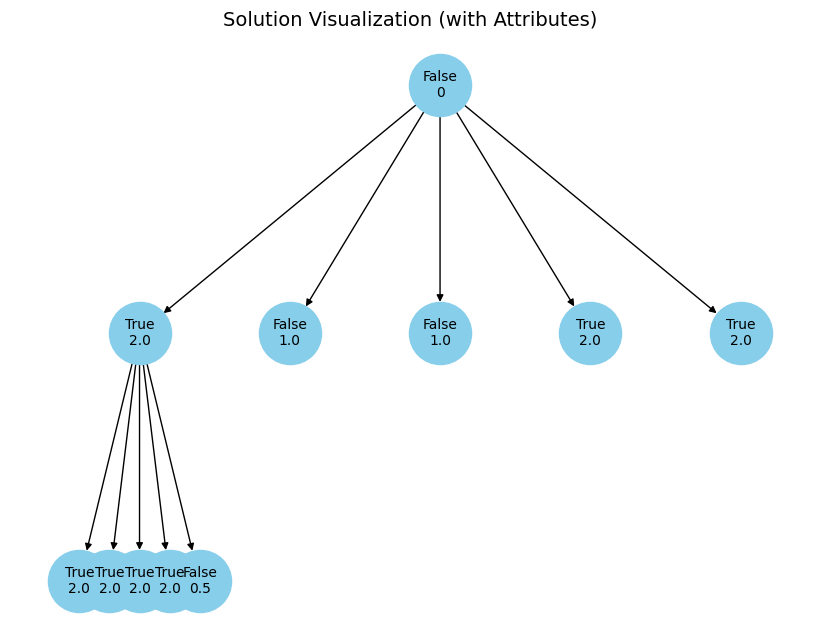

In [ ]:
def build_tree_from_dict(tree_dict, graph=None, parent=None):
    if graph is None:
        graph = nx.DiGraph()
    # Add node with attribute
    graph.add_node(tree_dict['id'], is_true=tree_dict['is_true'], reward=tree_dict['reward'])
    # Add edge from parent to current
    if parent is not None:
        graph.add_edge(parent, tree_dict['id'])
    # Recurse for children
    for child in tree_dict.get('children', []):
        build_tree_from_dict(child, graph, tree_dict['id'])
    return graph


def hierarchy_pos(G, root=None, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    if not nx.is_tree(G):
        raise TypeError("cannot use hierarchy_pos on a graph that is not a tree")

    if root is None:
        if isinstance(G, nx.DiGraph):
            root = [n for n, d in G.in_degree() if d == 0][0]
        else:
            root = list(G.nodes)[0]

    def _hierarchy_pos(G, root, leftmost, width, vert_gap, vert_loc, xcenter,
                       pos=None, parent=None, parsed=[]):
        if pos is None:
            pos = {root: (xcenter, vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
        children = list(G.successors(root))
        if len(children) != 0:
            dx = width / len(children)
            nextx = xcenter - width / 2 - dx / 2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(G, child, leftmost, dx, vert_gap, vert_loc - vert_gap,
                                     nextx, pos, root, parsed)
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_gap, vert_loc, xcenter)

with open('output/gsm8k/gemma-2-2b/22_034827/90.json', 'r') as fin:
    solution = json.load(fin)
print(solution['tree_lists'])
# Build graph
G = build_tree_from_dict(solution['tree_lists'])
print(G)
# Get hierarchical positions
pos = hierarchy_pos(G, root=0)
print(G.nodes(data=True))
labels = {n: f"{data['is_true']}\n{round(data['reward'], 2)}"
          for n, data in G.nodes(data=True)}

# Draw
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=False, node_size=2000, node_color="skyblue", arrows=True)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
plt.title("Solution Visualization (with Attributes)", fontsize=14)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap_with_borders(data, border_interval=5):
    # Create the heatmap
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(data, cmap='viridis', cbar=True, linewidths=0.5, linecolor='gray')

    # Add borders every 'border_interval' cells
    n = data.shape[0]
    for i in range(0, n, border_interval):
        ax.axhline(i, color='black', linewidth=2)
        ax.axvline(i, color='black', linewidth=2)

    # Add final border lines at the end
    ax.axhline(n, color='black', linewidth=2)
    ax.axvline(n, color='black', linewidth=2)

    plt.title(f'Heatmap with Borders Every {border_interval} Cells')
    plt.show()

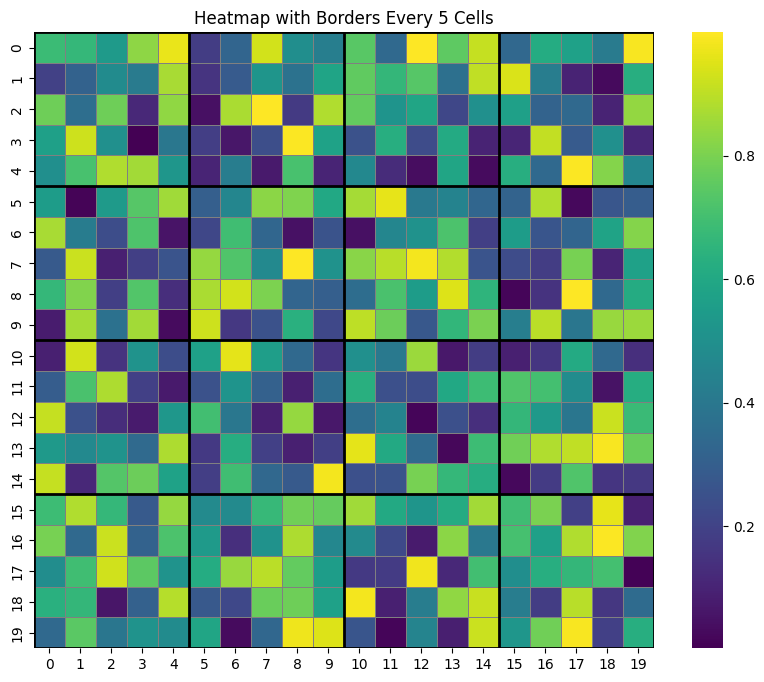

In [ ]:
data = np.random.rand(20, 20)
plot_heatmap_with_borders(data)
